# RecSys 2026 — Deep Exploratory Data Analysis

A comprehensive look at the TalkPlayData-Challenge dataset covering:
1. **Conversations** — structure, roles, turn patterns, goal categories
2. **Track catalog** — metadata, popularity, tags, duration, temporal patterns
3. **User profiles** — demographics, cold vs warm start
4. **Embeddings** — dimensionality, coverage, quick t-SNE visualization
5. **Cross-dataset joins** — which tracks appear in conversations, user-track overlap

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

DATA_DIR = Path('../data/raw')
print('Setup complete \u2705')

Setup complete ✅


---
## 1. Conversations

In [2]:
train_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Dataset/data/train-00000-of-00001.parquet')
dev_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Dataset/data/test-00000-of-00001.parquet')
blind_a = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Blind-A/data/test-00000-of-00001.parquet')

print(f'Train: {len(train_df):,} sessions')
print(f'Dev:   {len(dev_df):,} sessions')
print(f'Blind-A: {len(blind_a):,} sessions')
print(f'\nColumns: {list(train_df.columns)}')
print(f'\nDtypes:\n{train_df.dtypes}')

Train: 15,199 sessions
Dev:   1,000 sessions
Blind-A: 80 sessions

Columns: ['session_id', 'user_id', 'session_date', 'user_profile', 'conversation_goal', 'conversations', 'goal_progress_assessments']

Dtypes:
session_id                   object
user_id                      object
session_date                 object
user_profile                 object
conversation_goal            object
conversations                object
goal_progress_assessments    object
dtype: object


### 1.1 Conversation Structure

In [3]:
# Flatten all conversations into individual messages
def explode_conversations(df, split_name='train'):
    records = []
    for _, row in df.iterrows():
        for c in row['conversations']:
            records.append({
                'session_id': row['session_id'],
                'user_id': row['user_id'],
                'split': split_name,
                'turn_number': c['turn_number'],
                'role': c['role'],
                'content': c['content'],
                'thought': c.get('thought', ''),
                'content_len': len(c['content'].split()),
            })
    return pd.DataFrame(records)

train_msgs = explode_conversations(train_df, 'train')
dev_msgs = explode_conversations(dev_df, 'dev')

all_msgs = pd.concat([train_msgs, dev_msgs], ignore_index=True)
print(f'Total messages: {len(all_msgs):,}')
print(f'\nRole distribution:')
print(all_msgs['role'].value_counts())

Total messages: 388,776

Role distribution:
role
user         129592
music        129592
assistant    129592
Name: count, dtype: int64


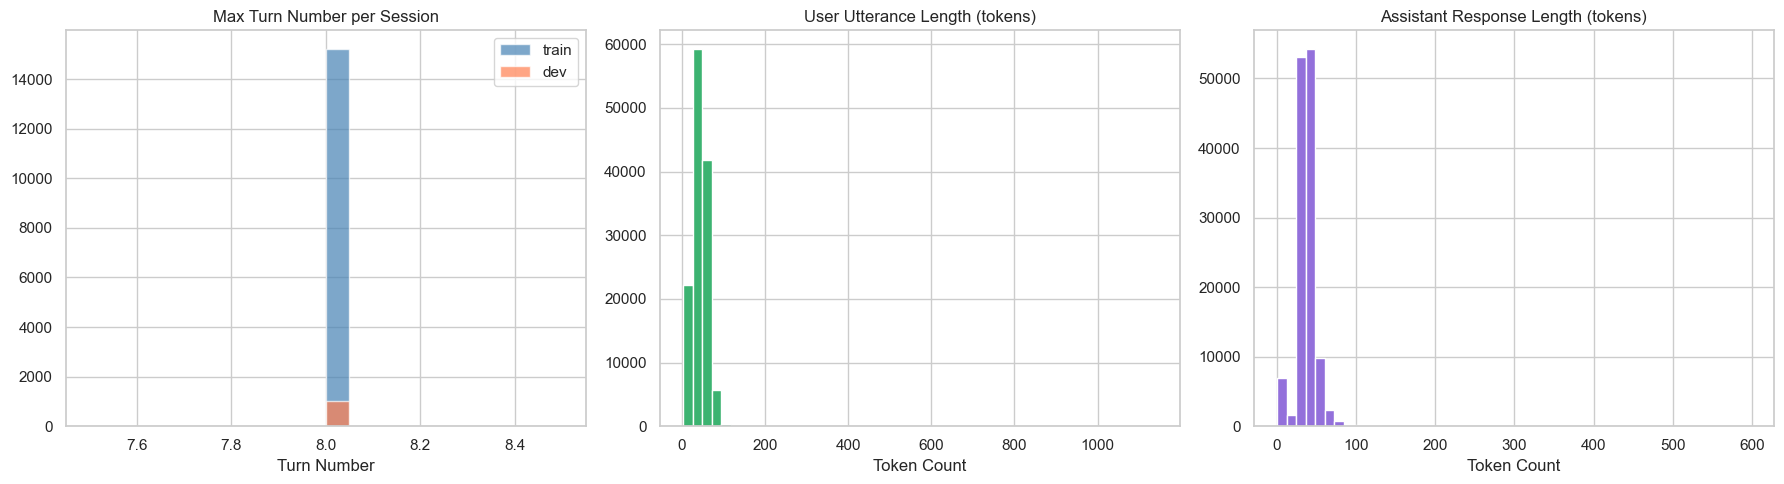

User utterance: mean=44.4, median=44
Asst response:  mean=37.1, median=37


In [4]:
# Turns per session
turns_per_session = all_msgs.groupby(['session_id', 'split'])['turn_number'].max().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Turns per session
for split, color in [('train', 'steelblue'), ('dev', 'coral')]:
    subset = turns_per_session[turns_per_session['split'] == split]
    axes[0].hist(subset['turn_number'], bins=20, alpha=0.7, color=color, label=split, edgecolor='white')
axes[0].set_title('Max Turn Number per Session')
axes[0].set_xlabel('Turn Number')
axes[0].legend()

# User message lengths
user_msgs = all_msgs[all_msgs['role'] == 'user']
axes[1].hist(user_msgs['content_len'], bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('User Utterance Length (tokens)')
axes[1].set_xlabel('Token Count')

# Assistant message lengths
asst_msgs = all_msgs[all_msgs['role'] == 'assistant']
axes[2].hist(asst_msgs['content_len'], bins=50, color='mediumpurple', edgecolor='white')
axes[2].set_title('Assistant Response Length (tokens)')
axes[2].set_xlabel('Token Count')

plt.tight_layout()
plt.show()

print(f'User utterance: mean={user_msgs["content_len"].mean():.1f}, median={user_msgs["content_len"].median():.0f}')
print(f'Asst response:  mean={asst_msgs["content_len"].mean():.1f}, median={asst_msgs["content_len"].median():.0f}')

### 1.2 Conversation Goals

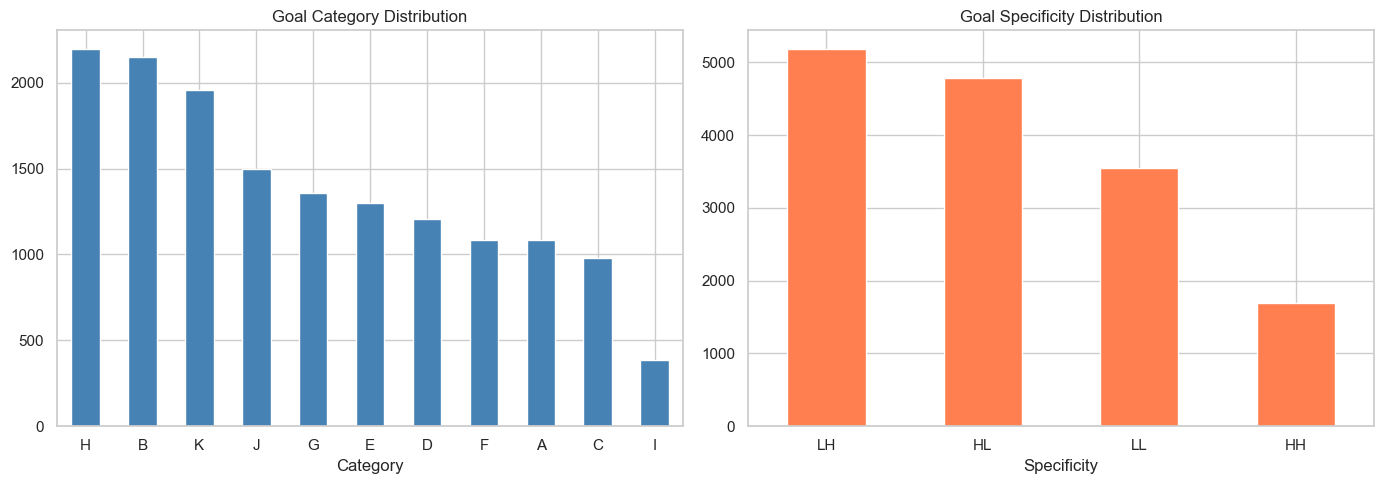


=== Sample Listener Goals by Category ===

[H] The listener wants to explore different artists and discover new songs from a broad collection, focusing on general moods and styles, without specific...

[K] discover multiple punk and alternative rock songs from the 2000s, exploring the sound of that era....

[D] find one specific Nine Inch Nails song that's perfect for a high-energy workout, but can't remember the name or specific details....

[C] find one specific album remembered by its distinctive and provocative cover art featuring an androgynous figure....

[F] find multiple Black Keys tracks with specific characteristics, such as gritty, lo-fi sound, prominent guitar riffs, or from particular albums/eras....

[J] find one specific song that was popular in the late 90s or early 2000s, perhaps a punk-rock or hip-hop track, but can't remember the exact title or ar...

[A] discover multiple mellow and pleasant songs for a relaxed atmosphere, focusing on acoustic or dreamy characteris

In [5]:
# Parse conversation_goal struct
train_df['goal_category'] = train_df['conversation_goal'].apply(lambda x: x.get('category', 'Unknown'))
train_df['goal_specificity'] = train_df['conversation_goal'].apply(lambda x: x.get('specificity', 'Unknown'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['goal_category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Goal Category Distribution')
axes[0].set_xlabel('Category')
axes[0].tick_params(axis='x', rotation=0)

train_df['goal_specificity'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Goal Specificity Distribution')
axes[1].set_xlabel('Specificity')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Show a listener_goal example for each category
print('\n=== Sample Listener Goals by Category ===')
for cat in train_df['goal_category'].unique():
    sample = train_df[train_df['goal_category'] == cat].iloc[0]['conversation_goal']
    print(f"\n[{cat}] {sample['listener_goal'][:150]}...")

### 1.3 Goal Progress Assessments

Goal progress assessments: 106,393

Assessment distribution:
assessment
MOVES_TOWARD_GOAL            53885
DOES_NOT_MOVE_TOWARD_GOAL    52508
Name: count, dtype: int64


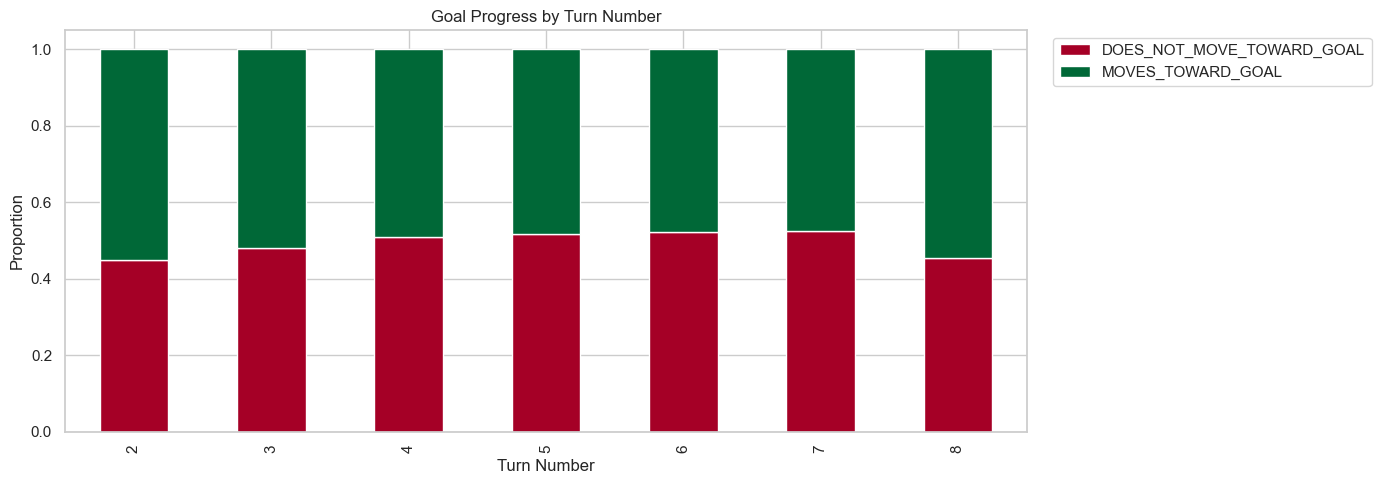

In [6]:
# Flatten goal progress assessments
gpa_records = []
for _, row in train_df.iterrows():
    for g in row['goal_progress_assessments']:
        if g['goal_progress_assessment'] is not None:
            gpa_records.append({
                'session_id': row['session_id'],
                'turn_number': g['turn_number'],
                'assessment': g['goal_progress_assessment'],
            })

gpa_df = pd.DataFrame(gpa_records)
print(f'Goal progress assessments: {len(gpa_df):,}')
print(f'\nAssessment distribution:')
print(gpa_df['assessment'].value_counts())

# Assessment by turn number
pivot = gpa_df.groupby(['turn_number', 'assessment']).size().unstack(fill_value=0)
if len(pivot) > 0:
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
    pivot_pct.head(10).plot(kind='bar', stacked=True, figsize=(14, 5), colormap='RdYlGn')
    plt.title('Goal Progress by Turn Number')
    plt.xlabel('Turn Number')
    plt.ylabel('Proportion')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### 1.4 Session Dates

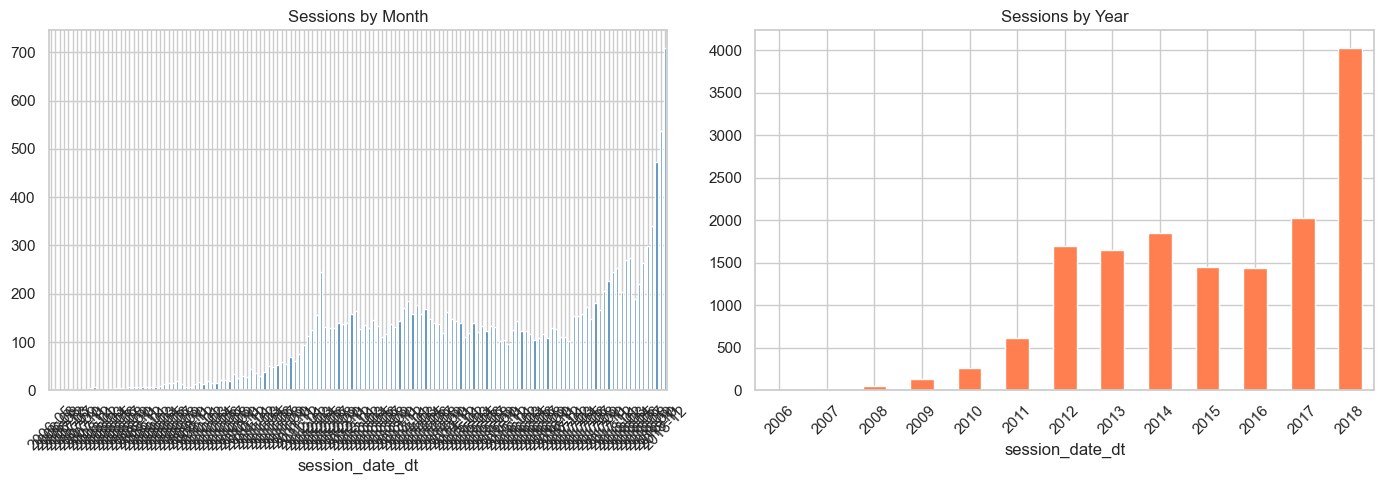

Date range: 2006-05-28 00:00:00 to 2018-12-31 00:00:00


In [7]:
train_df['session_date_dt'] = pd.to_datetime(train_df['session_date'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sessions over time
sessions_by_date = train_df['session_date_dt'].dt.to_period('M').value_counts().sort_index()
sessions_by_date.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Sessions by Month')
axes[0].tick_params(axis='x', rotation=45)

# Year distribution
train_df['session_date_dt'].dt.year.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Sessions by Year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Date range: {train_df["session_date_dt"].min()} to {train_df["session_date_dt"].max()}')

---
## 2. Track Catalog

In [8]:
tracks_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Track-Metadata/data/all_tracks-00000-of-00001.parquet')
test_tracks = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Track-Metadata/data/test_tracks-00000-of-00001.parquet')

print(f'All tracks: {len(tracks_df):,}')
print(f'Test tracks: {len(test_tracks):,}')
print(f'\nColumns: {list(tracks_df.columns)}')
print(f'\nMissing values:\n{tracks_df.isnull().sum()}')

All tracks: 47,071
Test tracks: 7,405

Columns: ['track_id', 'ISRC', 'track_name', 'artist_name', 'album_name', 'tag_list', 'popularity', 'release_date', 'duration', 'artist_id', 'album_id']

Missing values:
track_id        0
ISRC            0
track_name      0
artist_name     0
album_name      0
tag_list        0
popularity      0
release_date    0
duration        0
artist_id       0
album_id        0
dtype: int64


In [9]:
# Helper: extract first element from list columns
def first_elem(val):
    if isinstance(val, (list, np.ndarray)) and len(val) > 0:
        return val[0]
    return str(val) if pd.notna(val) else None

tracks_df['primary_artist'] = tracks_df['artist_name'].apply(first_elem)
tracks_df['primary_track_name'] = tracks_df['track_name'].apply(first_elem)
tracks_df['num_tags'] = tracks_df['tag_list'].apply(lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0)
tracks_df['duration_sec'] = tracks_df['duration'] / 1000.0
tracks_df['release_year'] = pd.to_datetime(tracks_df['release_date'], errors='coerce').dt.year

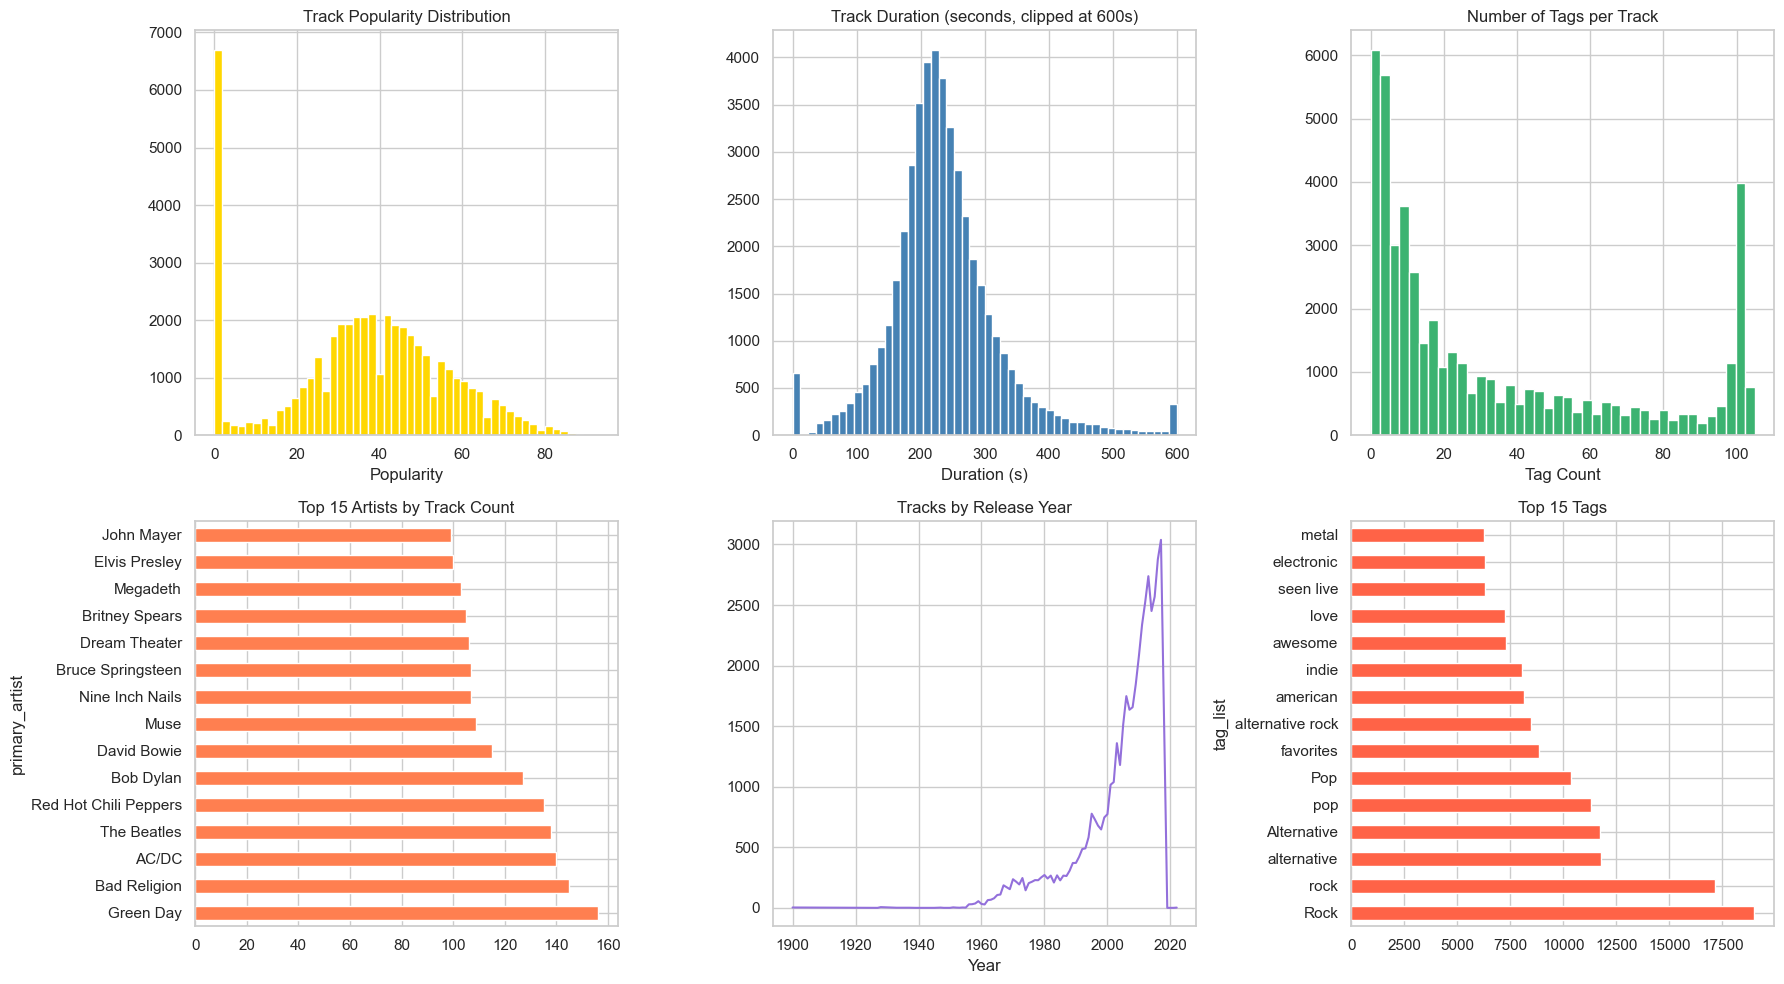

Popularity: mean=35.8, median=38
Duration: mean=236s, median=227s
Unique artists: 8,984
Unique tags: 164,133


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Popularity distribution
axes[0, 0].hist(tracks_df['popularity'].dropna(), bins=50, color='gold', edgecolor='white')
axes[0, 0].set_title('Track Popularity Distribution')
axes[0, 0].set_xlabel('Popularity')

# Duration distribution
dur = tracks_df['duration_sec'].clip(upper=600)  # clip at 10 min for viz
axes[0, 1].hist(dur.dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Track Duration (seconds, clipped at 600s)')
axes[0, 1].set_xlabel('Duration (s)')

# Tags per track
axes[0, 2].hist(tracks_df['num_tags'], bins=40, color='mediumseagreen', edgecolor='white')
axes[0, 2].set_title('Number of Tags per Track')
axes[0, 2].set_xlabel('Tag Count')

# Top 15 artists
tracks_df['primary_artist'].value_counts().head(15).plot(
    kind='barh', ax=axes[1, 0], color='coral'
)
axes[1, 0].set_title('Top 15 Artists by Track Count')

# Release year
year_counts = tracks_df['release_year'].dropna().astype(int).value_counts().sort_index()
year_counts.plot(ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Tracks by Release Year')
axes[1, 1].set_xlabel('Year')

# Top 15 tags
all_tags = tracks_df['tag_list'].dropna().explode()
all_tags.value_counts().head(15).plot(kind='barh', ax=axes[1, 2], color='tomato')
axes[1, 2].set_title('Top 15 Tags')

plt.tight_layout()
plt.show()

print(f'Popularity: mean={tracks_df["popularity"].mean():.1f}, median={tracks_df["popularity"].median():.0f}')
print(f'Duration: mean={tracks_df["duration_sec"].mean():.0f}s, median={tracks_df["duration_sec"].median():.0f}s')
print(f'Unique artists: {tracks_df["primary_artist"].nunique():,}')
print(f'Unique tags: {all_tags.nunique():,}')

---
## 3. User Profiles

In [11]:
users_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-User-Metadata/data/all_users-00000-of-00001.parquet')
print(f'Total users: {len(users_df):,}')
print(f'Columns: {list(users_df.columns)}')
print(f'\nMissing values:\n{users_df.isnull().sum()}')
users_df.describe()

Total users: 8,772
Columns: ['user_id', 'age', 'age_group', 'country_code', 'country_name', 'gender']

Missing values:
user_id         0
age             0
age_group       0
country_code    0
country_name    0
gender          0
dtype: int64


,age
count,8772.000000
mean,24.067487
std,6.522319
min,1.000000
25%,20.000000
50%,23.000000
75%,26.000000
max,71.000000


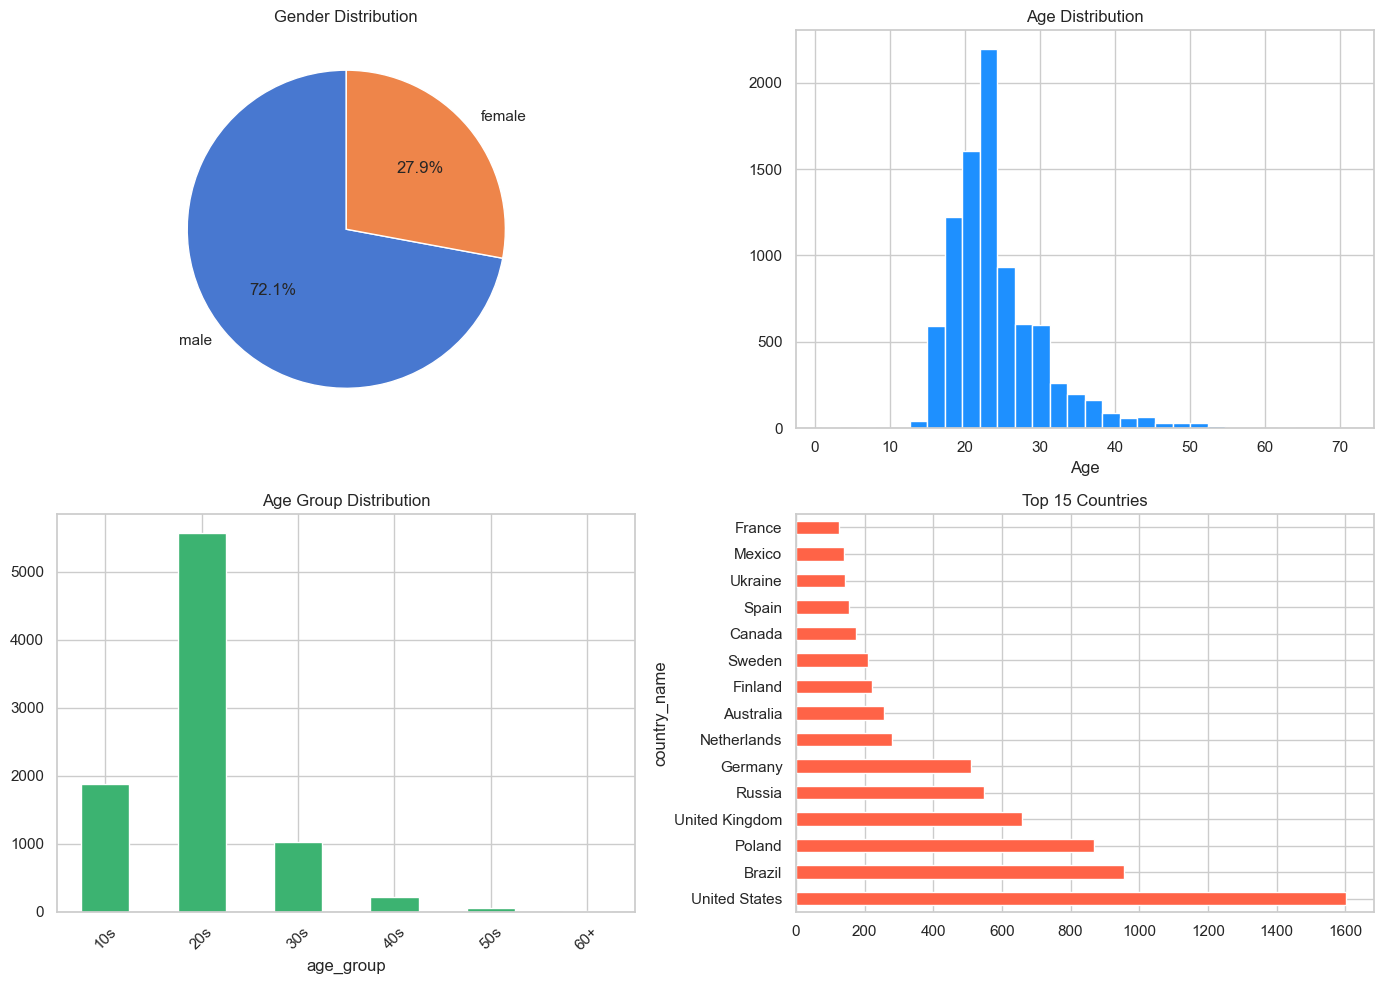

Age: mean=24.1, median=23
Countries: 129
Gender breakdown: {'male': np.int64(6323), 'female': np.int64(2449)}


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
users_df['gender'].value_counts().plot(kind='pie', ax=axes[0, 0], autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Gender Distribution')
axes[0, 0].set_ylabel('')

# Age
axes[0, 1].hist(users_df['age'].dropna(), bins=30, color='dodgerblue', edgecolor='white')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')

# Age groups
users_df['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Age Group Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

# Top countries
users_df['country_name'].value_counts().head(15).plot(kind='barh', ax=axes[1, 1], color='tomato')
axes[1, 1].set_title('Top 15 Countries')

plt.tight_layout()
plt.show()

print(f'Age: mean={users_df["age"].mean():.1f}, median={users_df["age"].median():.0f}')
print(f'Countries: {users_df["country_name"].nunique()}')
print(f'Gender breakdown: {dict(users_df["gender"].value_counts())}')

### 3.1 User Embeddings: Warm vs Cold Start

In [13]:
user_emb_train = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-User-Embeddings/data/train-00000-of-00001.parquet')
user_emb_warm = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-User-Embeddings/data/test_warm-00000-of-00001.parquet')
user_emb_cold = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-User-Embeddings/data/test_cold-00000-of-00001.parquet')

print(f'User embeddings - Train: {len(user_emb_train):,} | Test warm: {len(user_emb_warm):,} | Test cold: {len(user_emb_cold):,}')
print(f'Embedding dim: {len(user_emb_train["cf-bpr"].iloc[0])}')

# Cold users have no embedding (NaN or zero)
cold_sample = user_emb_cold['cf-bpr'].iloc[0]
print(f'\nCold user embedding sample (first 5): {cold_sample[:5] if isinstance(cold_sample, (list, np.ndarray)) else cold_sample}')
print(f'Warm user embedding sample (first 5): {user_emb_warm["cf-bpr"].iloc[0][:5]}')

User embeddings - Train: 8,591 | Test warm: 371 | Test cold: 129
Embedding dim: 128

Cold user embedding sample (first 5): []
Warm user embedding sample (first 5): [ 0.00884264  0.00435285  0.0017126   0.00431917 -0.00668646]


### 3.2 User Profiles from Conversations

In [14]:
# The conversation data also embeds user profile info
conv_profiles = pd.json_normalize(train_df['user_profile'])
print(f'Profile fields: {list(conv_profiles.columns)}')
print(f'\nUser splits in conversations:')
print(conv_profiles['user_split'].value_counts())

print(f'\nPreferred languages:')
print(conv_profiles['preferred_language'].value_counts().head(10))

print(f'\nPreferred musical cultures:')
print(conv_profiles['preferred_musical_culture'].value_counts().head(10))

Profile fields: ['age', 'age_group', 'country_code', 'country_name', 'gender', 'preferred_language', 'preferred_musical_culture', 'user_id', 'user_split']

User splits in conversations:
user_split
train_warm    15199
Name: count, dtype: int64

Preferred languages:
preferred_language
English    15199
Name: count, dtype: int64

Preferred musical cultures:
preferred_musical_culture
Western                     976
American                    594
Anglo-American              420
North American              327
Western Pop Culture         284
Alternative Rock Culture    252
American Hip-Hop            219
American Pop Culture        213
Western Rock Culture        203
American Rock Culture       193
Name: count, dtype: int64


---
## 4. Track Embeddings

In [15]:
# Load test track embeddings (smaller, faster)
track_emb = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Track-Embeddings/data/test_tracks-00000-of-00001.parquet')
print(f'Test track embeddings: {len(track_emb):,}')
print(f'Columns: {list(track_emb.columns)}')

# Check embedding dimensions
emb_cols = [c for c in track_emb.columns if c != 'track_id']
for col in emb_cols:
    sample = track_emb[col].iloc[0]
    dim = len(sample) if isinstance(sample, (list, np.ndarray)) else 'N/A'
    has_nans = track_emb[col].apply(lambda x: any(np.isnan(v) for v in x) if isinstance(x, (list, np.ndarray)) else True).sum()
    print(f'  {col}: dim={dim}, NaN rows={has_nans}')

Test track embeddings: 7,405
Columns: ['track_id', 'audio-laion_clap', 'image-siglip2', 'cf-bpr', 'attributes-qwen3_embedding_0.6b', 'lyrics-qwen3_embedding_0.6b', 'metadata-qwen3_embedding_0.6b']
  audio-laion_clap: dim=512, NaN rows=0
  image-siglip2: dim=768, NaN rows=0
  cf-bpr: dim=128, NaN rows=0
  attributes-qwen3_embedding_0.6b: dim=1024, NaN rows=0
  lyrics-qwen3_embedding_0.6b: dim=1024, NaN rows=0
  metadata-qwen3_embedding_0.6b: dim=1024, NaN rows=0


In [16]:
# Quick t-SNE of cf-bpr track embeddings (first 2000 for speed)
from sklearn.manifold import TSNE

N_SAMPLE = 2000
emb_col = 'cf-bpr'

sample_emb = track_emb.head(N_SAMPLE)

# Some tracks have empty embeddings (length 0) — filter them out before stacking
emb_lengths = sample_emb[emb_col].apply(len)
expected_dim = emb_lengths[emb_lengths > 0].iloc[0]
valid_rows = sample_emb[emb_lengths == expected_dim]
print(f'Tracks with valid {emb_col} (dim={expected_dim}): {len(valid_rows)} / {N_SAMPLE}  ({N_SAMPLE - len(valid_rows)} empty)')

X = np.stack(valid_rows[emb_col].values)

# Also drop any rows with NaN
nan_mask = ~np.isnan(X).any(axis=1)
X_valid = X[nan_mask]
print(f'After NaN filter: {X_valid.shape[0]} embeddings')

if X_valid.shape[0] > 100:
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
    X_2d = tsne.fit_transform(X_valid)

    plt.figure(figsize=(10, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], s=5, alpha=0.5, c='steelblue')
    plt.title(f't-SNE of {emb_col} Track Embeddings (n={X_valid.shape[0]})')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough valid embeddings for t-SNE')

Tracks with valid cf-bpr (dim=128): 1833 / 2000  (167 empty)
After NaN filter: 1833 embeddings


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

---
## 5. Cross-Dataset Analysis

In [ ]:
# Extract all track_ids mentioned in conversations (role='music')
def get_conversation_track_ids(df):
    track_ids = []
    for convs in df['conversations']:
        for c in convs:
            if c['role'] == 'music':
                track_ids.append(c['content'])
    return track_ids

train_track_ids = get_conversation_track_ids(train_df)
dev_track_ids = get_conversation_track_ids(dev_df)

catalog_ids = set(tracks_df['track_id'])

print(f'Unique tracks in train conversations: {len(set(train_track_ids)):,}')
print(f'Unique tracks in dev conversations:   {len(set(dev_track_ids)):,}')
print(f'Catalog size: {len(catalog_ids):,}')
print(f'\nTrain tracks in catalog: {len(set(train_track_ids) & catalog_ids):,} / {len(set(train_track_ids)):,}')
print(f'Dev tracks in catalog:   {len(set(dev_track_ids) & catalog_ids):,} / {len(set(dev_track_ids)):,}')
print(f'\nOverlap (train & dev tracks): {len(set(train_track_ids) & set(dev_track_ids)):,}')

In [ ]:
# Track frequency in conversations (how many times is each track recommended?)
track_freq = Counter(train_track_ids)
freq_values = list(track_freq.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(freq_values, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Track Recommendation Frequency (Train)')
axes[0].set_xlabel('Times Recommended')
axes[0].set_ylabel('Number of Tracks')

# Top recommended tracks
top_tracks = pd.DataFrame(track_freq.most_common(15), columns=['track_id', 'count'])
top_tracks = top_tracks.merge(tracks_df[['track_id', 'primary_track_name', 'primary_artist']], on='track_id', how='left')
top_tracks['label'] = top_tracks['primary_track_name'].fillna('') + ' - ' + top_tracks['primary_artist'].fillna('')

axes[1].barh(top_tracks['label'], top_tracks['count'], color='coral')
axes[1].set_title('Top 15 Most Recommended Tracks')
axes[1].set_xlabel('Times Recommended')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# User overlap between splits
train_users = set(train_df['user_id'])
dev_users = set(dev_df['user_id'])
catalog_users = set(users_df['user_id'])

print(f'Users in train: {len(train_users):,}')
print(f'Users in dev:   {len(dev_users):,}')
print(f'Users in catalog: {len(catalog_users):,}')
print(f'\nTrain & dev overlap: {len(train_users & dev_users):,}')
print(f'Dev users in catalog: {len(dev_users & catalog_users):,} / {len(dev_users):,}')

# Sessions per user
sessions_per_user = train_df['user_id'].value_counts()
print(f'\nSessions per user: mean={sessions_per_user.mean():.1f}, max={sessions_per_user.max()}')

---
## 6. Summary Statistics

In [ ]:
summary = {
    'Train sessions': len(train_df),
    'Dev sessions': len(dev_df),
    'Blind-A sessions': len(blind_a),
    'Track catalog size': len(tracks_df),
    'Unique artists': tracks_df['primary_artist'].nunique(),
    'Unique tags': all_tags.nunique(),
    'Total users': len(users_df),
    'Warm test users': len(user_emb_warm),
    'Cold test users': len(user_emb_cold),
    'Unique tracks in train': len(set(train_track_ids)),
    'Unique tracks in dev': len(set(dev_track_ids)),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df['Value'] = summary_df['Value'].apply(lambda x: f'{x:,}')
print(summary_df.to_string(index=False))